# Intent Classification Demonstration

This notebook demonstrates the step-by-step process of training an Intent Classification model using TF-IDF and SVM, preserving the logic from the original `IntentClassifier` class.

## 1. Imports
We start by importing the necessary libraries for data handling, machine learning, and visualization.

In [7]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## 2. Dataset Loading
We load the dataset from the JSON file. The dataset contains text examples and their corresponding intents.

In [8]:
dataset_path = '../../data/dataset.json'
print(f"Loading dataset from {dataset_path}...")

with open(dataset_path, 'r') as f:
    data = json.load(f)

texts = [item['text'] for item in data]
labels = [item['intent'] for item in data]
print(f"Loaded {len(texts)} examples.")

Loading dataset from ../../data/dataset.json...
Loaded 247 examples.


## 3. Convert Dataset into DataFrame
Converting the data into a Pandas DataFrame for easier manipulation and visualization.

In [9]:
df = pd.DataFrame({
    'text': texts,
    'intent': labels
})
print("DataFrame created.")

DataFrame created.


## 4. Show Sample Data
Reviewing the first few rows of our dataset.

In [10]:
df.head()

,text,intent
0,open chrome,open_app
1,launch chrome,open_app
2,start chrome,open_app
3,run chrome,open_app
4,open up chrome,open_app


## 5. Show Intent Distribution
Visualizing the distribution of intents to ensure we have a balanced or representative dataset.

intent
open_app          53
close_app         41
system_control    27
web_search        23
music_control     21
file_operation    20
file_search       15
time_date         15
greetings         12
weather           10
help              10
Name: count, dtype: int64


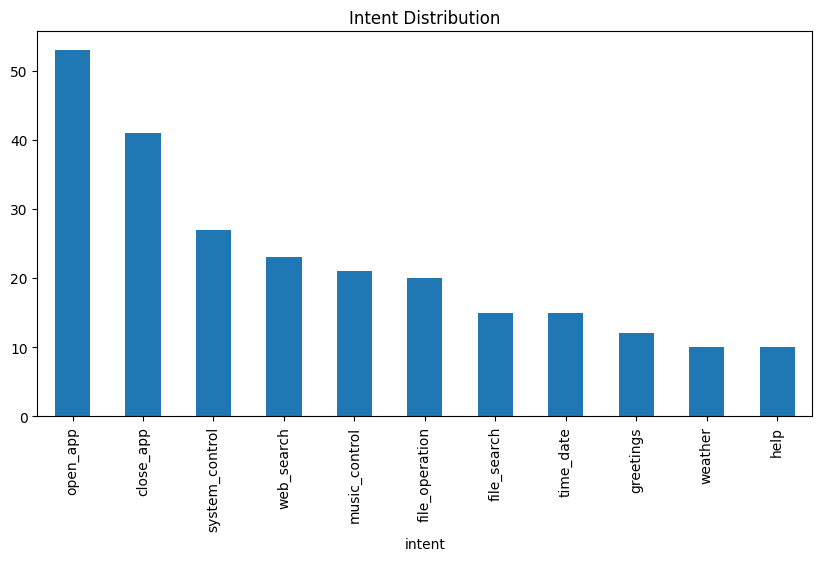

In [11]:
dist = df['intent'].value_counts()
print(dist)

# Note: In a live environment, this would show a bar plot
plt.figure(figsize=(10, 5))
dist.plot(kind='bar')
plt.title('Intent Distribution')
plt.show()

## 6. Train-Test Split
Splitting the data into training and testing sets (80% training, 20% testing).

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 197
Test set size: 50


## 7. Model Creation
Creating a Pipeline that combines TF-IDF Vectorization with an SVM Classifier.

In [13]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
    ('clf', SVC(kernel='linear', probability=True))
])
print("Model pipeline created.")

Model pipeline created.


## 8. Model Training
Training the pipeline on our training data.

In [14]:
print("Training model...")
model.fit(X_train, y_train)
print("Training complete.")

Training model...
Training complete.


## 9. Model Evaluation
Evaluating the model performance on the test set using a classification report.

In [15]:
print("Evaluating model...")
predictions = model.predict(X_test)
report = classification_report(y_test, predictions)
print(f"Classification Report:\n{report}")

Evaluating model...
Classification Report:
                precision    recall  f1-score   support

     close_app       1.00      1.00      1.00         6
file_operation       1.00      0.67      0.80         3
   file_search       0.00      0.00      0.00         2
     greetings       1.00      0.20      0.33         5
          help       1.00      0.50      0.67         2
 music_control       0.75      0.60      0.67         5
      open_app       0.92      0.92      0.92        13
system_control       0.33      1.00      0.50         4
     time_date       1.00      1.00      1.00         3
       weather       1.00      0.67      0.80         3
    web_search       0.80      1.00      0.89         4

      accuracy                           0.76        50
     macro avg       0.80      0.69      0.69        50
  weighted avg       0.85      0.76      0.75        50



## 10. Model Saving
Saving the trained model to disk for later use.

In [16]:
model_path = '../../data/models/intent_model_demo.pkl'
directory = os.path.dirname(model_path)
if not os.path.exists(directory):
    os.makedirs(directory)

with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved to {model_path}")

Model saved to ../../data/models/intent_model_demo.pkl


## 11. Prediction Function
Defining a function to predict intents for new text inputs, mirroring the `predict` method from the class.

In [17]:
def predict_intent(text):
    """Predict intent for a given text"""
    try:
        probas = model.predict_proba([text])[0]
        max_index = np.argmax(probas)
        confidence = probas[max_index]
        intent = model.classes_[max_index]
        
        return {
            "intent": intent,
            "confidence": float(confidence)
        }
    except Exception as e:
        print(f"Prediction failed: {e}")
        return {"intent": "unknown", "confidence": 0.0}

## 12. Test Predictions
Testing the model with sample voice commands.

In [18]:
test_queries = [
    "open chrome",
    "search for python on google",
    "what is the weather like today",
    "play some music",
    "create a new folder called work"
]

for query in test_queries:
    result = predict_intent(query)
    print(f"Query: '{query}'")
    print(f"Predicted Intent: {result['intent']} (Confidence: {result['confidence']:.2f})")
    print("-" * 30)

Query: 'open chrome'
Predicted Intent: open_app (Confidence: 0.97)
------------------------------
Query: 'search for python on google'
Predicted Intent: web_search (Confidence: 0.37)
------------------------------
Query: 'what is the weather like today'
Predicted Intent: weather (Confidence: 0.40)
------------------------------
Query: 'play some music'
Predicted Intent: music_control (Confidence: 0.96)
------------------------------
Query: 'create a new folder called work'
Predicted Intent: file_operation (Confidence: 0.57)
------------------------------
